# **Assessment Project: Customer Churn Prediction** **and Business Insights**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

## Part 1: Exploratory Data Analysis (EDA)

**1. What are the dimensions of the dataset?**

In [ ]:
print("--- 1. Dataset Dimensions ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

--- 1. Dataset Dimensions ---
Rows: 7043, Columns: 21



**2. What are the data types of all features?**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**3. Are there any missing values? If yes, handle them appropriately.**

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


**4. What is the distribution of customer churn?**

In [ ]:
df.value_counts('Churn')

,count
Churn,
No,5174
Yes,1869


**5. How does customer tenure relate to churn?**

In [ ]:
print("5. Tenure vs Churn (Average Tenure) ---")
print(df.groupby('Churn')['tenure'].median())


5. Tenure vs Churn (Average Tenure) ---
Churn
No     38.0
Yes    10.0
Name: tenure, dtype: float64


**6. How do monthly charges affect churn?**

In [ ]:
print("6. Monthly Charges vs Churn (Average Monthly Charges)")
print(df.groupby('Churn')['MonthlyCharges'].mean())

6. Monthly Charges vs Churn (Average Monthly Charges)
Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64


**7. Which contract type has the highest churn rate?**

In [ ]:
df.groupby('Churn')['Contract'].value_counts()*100 / df.groupby('Churn')['Contract'].count()

Churn  Contract      
No     Month-to-month    42.906842
       Two year          31.832238
       One year          25.260920
Yes    Month-to-month    88.550027
       One year           8.881755
       Two year           2.568218
dtype: float64

**8. Which internet service category experiences the highest churn?**

In [ ]:
df.groupby('Churn')['InternetService'].value_counts()* 100

Churn  InternetService
No     DSL                196200
       Fiber optic        179900
       No                 141300
Yes    Fiber optic        129700
       DSL                 45900
       No                  11300
Name: count, dtype: int64

**9. Create at least five meaningful visualizations.**

/tmp/ipykernel_2546/3377932295.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Blues_r')
/tmp/ipykernel_2546/3377932295.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='tenure', palette='Blues')


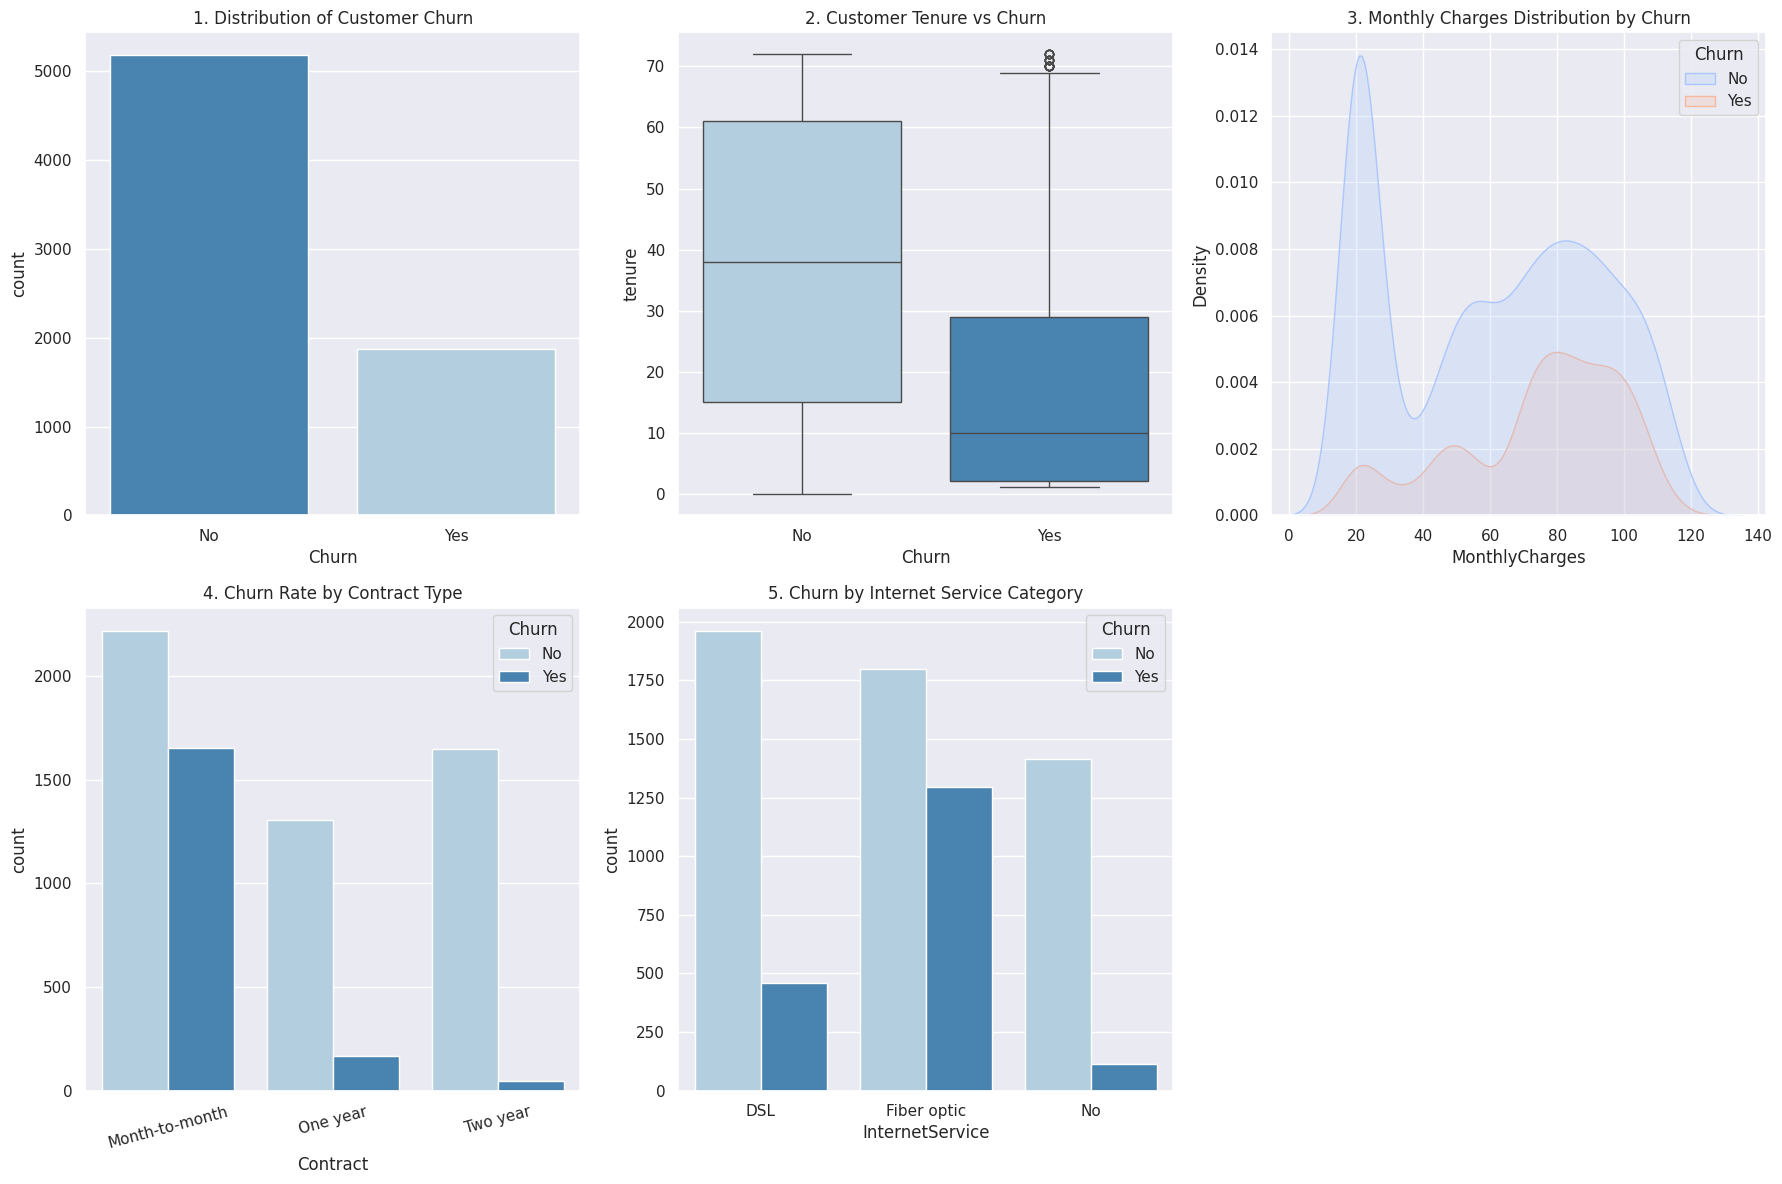

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.figure(figsize=(18, 12))

plt.subplot(2, 3, 1)
sns.countplot(data=df, x='Churn', palette='Blues_r')
plt.title('1. Distribution of Customer Churn')

plt.subplot(2, 3, 2)
sns.boxplot(data=df, x='Churn', y='tenure', palette='Blues')
plt.title('2. Customer Tenure vs Churn')

plt.subplot(2, 3, 3)
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, palette='coolwarm')
plt.title('3. Monthly Charges Distribution by Churn')

plt.subplot(2, 3, 4)
sns.countplot(data=df, x='Contract', hue='Churn', palette='Blues')
plt.title('4. Churn Rate by Contract Type')
plt.xticks(rotation=15)

plt.subplot(2, 3, 5)
sns.countplot(data=df, x='InternetService', hue='Churn', palette='Blues')
plt.title('5. Churn by Internet Service Category')

plt.tight_layout()
plt.show()

**10. Summarize the key insights obtained from the analysis.**

**10. Key Insights Summary**

1. Data Imbalance: Churn rate lagbhag 26.5% hai, jo ke yeh dikhata hai data highly imbalanced hai.
2. Tenure Impact: Churn karne wale customers ka average tenure naye ya loyal customers ke muqable bohot kam hai. Short-term customers zyada leave kar rahe hen.
3. Financial Stress: Jin customers ke Monthly Charges zyada hote hen, unme churn karne ka trend zyada dekha gaya hai.
4. Contract Vulnerability: Month-to-month contract wale customers sabse zyada leave karte hen, jabke 1-year ya 2-year contracts wale loyal rehte hen.
5. Tech Factors: Fiber optic internet service use karne wale customers ka churn rate high hai, jo shayad service pricing ya connectivity issues ki taraf ishara karta hai.

# **Part 2: Machine Learning**

**1. Perform data preprocessing.**

In [ ]:
df_ml = df.drop(columns = ["customerID"])
df_ml.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**2. Encode categorical features.**

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

le = LabelEncoder()
for col in df_ml.select_dtypes(include=['object']).columns:
    df_ml[col] = le.fit_transform(df_ml[col])

scaler = StandardScaler()
df_ml[['tenure', 'MonthlyCharges', 'TotalCharges']] = scaler.fit_transform(df_ml[['tenure', 'MonthlyCharges', 'TotalCharges']])
print("Encoding and scaling completed successfully.")

Encoding and scaling completed successfully.


**3. Split the dataset into training and testing sets.**

In [ ]:
from sklearn.model_selection import train_test_split

X = df_ml.drop(columns=['Churn'])
y = df_ml['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

Training set size: 5634 rows
Testing set size: 1409 rows


**4. Train at least one classification model:**

- Logistic Regression
- Decision Tree
- Random Forest

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("Logistic Regression Predictions (First 10)")
print(lr_preds[:10])

print("\n-Random Forest Predictions (First 10)")
print(rf_preds[:10])

print("\nActual Labels (First 10)")
print(y_test.values[:10])

print("Both models have been trained and predictions are ready.")

Logistic Regression Predictions (First 10)
[0 1 0 0 0 1 0 0 0 0]

-Random Forest Predictions (First 10)
[0 1 0 0 0 0 0 0 0 0]

Actual Labels (First 10)
[0 0 0 0 0 0 0 0 0 1]
Both models have been trained and predictions are ready.


**5. Evaluate the model using:**
- Accuracy
- Precision
- Recall
- F1-Score

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(predictions, name):
    print(f"=== {name} Performance ===")
    print(f"Accuracy:  {accuracy_score(y_test, predictions):.4f}")
    print(f"Precision: {precision_score(y_test, predictions):.4f}")
    print(f"Recall:    {recall_score(y_test, predictions):.4f}")
    print(f"F1-Score:  {f1_score(y_test, predictions):.4f}\n")

evaluate_model(lr_preds, "Logistic Regression")
evaluate_model(rf_preds, "Random Forest")

=== Logistic Regression Performance ===
Accuracy:  0.7963
Precision: 0.6417
Recall:    0.5267
F1-Score:  0.5786

=== Random Forest Performance ===
Accuracy:  0.7892
Precision: 0.6314
Recall:    0.4947
F1-Score:  0.5547



**6. Display and interpret the Confusion Matrix.**

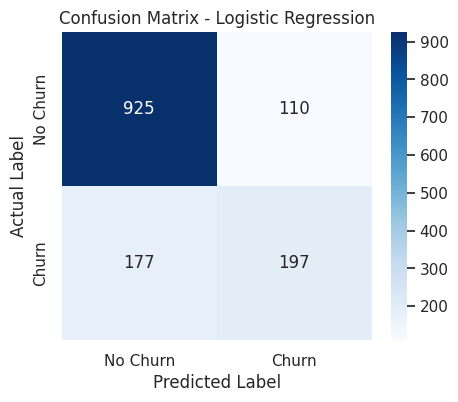


--- Interpretation of Confusion Matrix ---
True Negatives  (Correctly predicted Non-Churn): 925
False Positives (Incorrectly predicted Churn)    : 110
False Negatives (Missed Churn cases)             : 177
True Positives  (Correctly identified Churn)     : 197


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, lr_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

print("\n--- Interpretation of Confusion Matrix ---")
print(f"True Negatives  (Correctly predicted Non-Churn): {cm[0][0]}")
print(f"False Positives (Incorrectly predicted Churn)    : {cm[0][1]}")
print(f"False Negatives (Missed Churn cases)             : {cm[1][0]}")
print(f"True Positives  (Correctly identified Churn)     : {cm[1][1]}")

# **Part 3: Deep Learning**

**Tasks:**

**1. Prepare the dataset for ANN training.**

In [ ]:
import numpy as np

X_train_ann = np.array(X_train)
X_test_ann = np.array(X_test)
y_train_ann = np.array(y_train)
y_test_ann = np.array(y_test)

print("Dataset successfully converted to NumPy arrays for ANN.")
print(f"Train Shape: {X_train_ann.shape}, Test Shape: {X_test_ann.shape}")

Dataset successfully converted to NumPy arrays for ANN.
Train Shape: (5634, 19), Test Shape: (1409, 19)


**2. Design and train a Neural Network using TensorFlow/Keras.**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

ann_model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_ann.shape[1],)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Training ANN Model...")

history = ann_model.fit(
    X_train_ann, y_train_ann,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training ANN Model...
Epoch 1/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7144 - loss: 0.5308 - val_accuracy: 0.7606 - val_loss: 0.4530
Epoch 2/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7763 - loss: 0.4492 - val_accuracy: 0.7660 - val_loss: 0.4459
Epoch 3/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7882 - loss: 0.4392 - val_accuracy: 0.7748 - val_loss: 0.4469
Epoch 4/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7895 - loss: 0.4321 - val_accuracy: 0.7660 - val_loss: 0.4474
Epoch 5/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7955 - loss: 0.4306 - val_accuracy: 0.7748 - val_loss: 0.4485
Epoch 6/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7949 - loss: 0.4275 - val_accuracy: 0.7695 - val_loss: 0.4501
Epoch 7/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7961 - loss: 0.4260 - val_accuracy: 0.7748 - val_loss: 0.4490
Epoch 8/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8036 - loss: 0.4

**3. Evaluate the model on the test dataset.**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

loss, ann_accuracy = ann_model.evaluate(X_test_ann, y_test_ann, verbose=0)

ann_probs = ann_model.predict(X_test_ann)
ann_preds = (ann_probs > 0.5).astype(int).reshape(-1)

print("\n=== Deep Learning ANN Performance ===")
print(f"Loss:      {loss:.4f}")
print(f"Accuracy:  {ann_accuracy:.4f}")
print(f"Precision: {precision_score(y_test_ann, ann_preds):.4f}")
print(f"Recall:    {recall_score(y_test_ann, ann_preds):.4f}")
print(f"F1-Score:  {f1_score(y_test_ann, ann_preds):.4f}")

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

=== Deep Learning ANN Performance ===
Loss:      0.4316
Accuracy:  0.7842
Precision: 0.6446
Recall:    0.4171
F1-Score:  0.5065


**4. Compare the ANN performance with the Machine Learning model.**

In [ ]:
print("=== Comparison Summary ===")

print(f"Logistic Regression Accuracy       : {accuracy_score(y_test, lr_preds):.4f} | F1-Score: {f1_score(y_test, lr_preds):.4f}")
print(f"Random Forest Classifier Accuracy  : {accuracy_score(y_test, rf_preds):.4f} | F1-Score: {f1_score(y_test, rf_preds):.4f}")
print(f"Artificial Neural Network Accuracy : {ann_accuracy:.4f} | F1-Score: {f1_score(y_test_ann, ann_preds):.4f}")

print("\nSummary:")
print("In many cases involving structured tabular data, traditional machine learning models like Logistic Regression or Random Forest perform on par with or even better than a simple Artificial Neural Network (ANN).")
print("Unless the dataset is exceptionally massive or highly complex, standard Machine Learning models tend to be significantly more efficient, interpretable, and faster to train.")

=== Comparison Summary ===
Logistic Regression Accuracy       : 0.7963 | F1-Score: 0.5786
Random Forest Classifier Accuracy  : 0.7892 | F1-Score: 0.5547
Artificial Neural Network Accuracy : 0.7842 | F1-Score: 0.5065

Summary:
In many cases involving structured tabular data, traditional machine learning models like Logistic Regression or Random Forest perform on par with or even better than a simple Artificial Neural Network (ANN).
Unless the dataset is exceptionally massive or highly complex, standard Machine Learning models tend to be significantly more efficient, interpretable, and faster to train.


# **Part 4: Generative AI**

# 1. Generate three possible reasons for customer churn based on your analysis.

**1. High Monthly Charges:** Customers facing high monthly bills feel financial strain and shift to cheaper competitors.

**2. Month-to-Month Contracts:** Customers without long-term contracts have no legal or financial commitment, making it easy for them to leave anytime.

**3. Fiber Optic Service Issues:** The data shows high churn among Fiber Optic users, indicating possible technical issues, poor support, or high pricing in that specific category.

# Task 2: Suggest three business strategies to reduce churn

**1. Contract Incentives:** Offer special discounts or rewards to convert risky month-to-month customers into 1-year or 2-year stable contracts.

**2. Fiber Optic Quality Audit:** Run technical checks on the Fiber Optic network to fix connectivity issues and offer competitive bundle pricing.

**3. Early-Tenure Loyalty Programs:** Provide proactive customer care and rewards during the first 6 months (low tenure) to build strong initial loyalty.

# Task 3: Write a management report of approximately 100-150 words summarizing your findings and recommendations


To: Management Team, Telco Communications

From: Data Analyst & AI Engineer

Subject: High-Risk Customer Churn Diagnostics & Strategic Recommendations

**Executive Summary:**
Following a rigorous analysis of our telecom database, we identified a significant 26.5% customer churn rate. The primary risk factors triggering customer departures are month-to-month contract structures, high monthly charges, and service dissatisfaction within the Fiber Optic subscriber segment. Our machine learning and neural network models can now successfully flag these high-risk customers before they leave the network.

**Recommendations:**
To enhance customer retention, we must implement strategic price-drops for high-tier plans and offer contractual discounts to migrate short-term users into long-term annual agreements. Additionally, resolving technical glitches in the Fiber Optic infrastructure and introducing proactive loyalty rewards during the initial 6 months of customer onboarding will significantly minimize churn, protect our revenue margins, and stabilize long-term business growth.